In [2]:
#!pip install gprofiler-official goatools keggrest

In [3]:
#!pip install GEOparse

## Data Extraction & Preprocessing

In [1]:
# Extracts & Preprocesses two gene expression datasets.

import pandas as pd
import io

def convert_soft_to_csv(soft_file, csv_file):
    with open(soft_file, "r") as file:
        lines = file.readlines()

    # Find the start of the table
    start_idx = None
    for i, line in enumerate(lines):
        if line.startswith("!dataset_table_begin"):
            start_idx = i + 1  # Data starts on the next line
            break

    if start_idx is None:
        raise ValueError("Table not found in the SOFT file.")

    # Extract the table lines
    table_data = lines[start_idx:]

    # Convert to DataFrame
    df = pd.read_csv(io.StringIO("".join(table_data)), sep="\t", low_memory=False)

    # Save to CSV
    df.to_csv(csv_file, index=False)
    print(f"Saved: {csv_file}")

# Convert both datasets
convert_soft_to_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646_full.soft", "GDS5646.csv")
convert_soft_to_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS6063_full.soft", "GDS6063.csv")  # Load extracted data


Saved: GDS5646.csv
Saved: GDS6063.csv


## Loading Data and Selecting Relevant Columns

In [2]:
# Now that the CSVs are saved, load them into DataFrames
pd_genes = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646.csv", usecols=["Gene symbol"] + [col for col in pd.read_csv("GDS5646.csv", nrows=1).columns if "GSM" in col])
inf_genes = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS6063.csv", usecols=["Gene symbol"] + [col for col in pd.read_csv("GDS6063.csv", nrows=1).columns if "GSM" in col])


## Cleaning Gene Symbols

In [3]:
# Standardize gene symbols
pd_genes["Gene symbol"] = pd_genes["Gene symbol"].str.upper().str.strip()
inf_genes["Gene symbol"] = inf_genes["Gene symbol"].str.upper().str.strip()

# Remove empty values
pd_genes = pd_genes.dropna()
inf_genes = inf_genes.dropna()

inf_genes.head()


,GSM1684096,GSM1684098,GSM1684100,GSM1684102,GSM1684104,GSM1684095,GSM1684097,GSM1684099,GSM1684101,GSM1684103,Gene symbol
9,22303.3000,24776.100,26775.300,25980.2000,26775.3000,23599.300,25980.200,24776.1000,25980.200,23599.300,EEF1A1
10,7732.6500,5296.750,6430.160,4801.0300,5654.9400,6405.330,6553.480,7699.2200,6648.160,8646.440,GAPDH
782,97.2257,100.547,109.053,94.7451,107.9070,95.652,105.754,119.3260,111.958,115.324,SLC35E2
783,97.0978,102.292,119.790,105.9600,94.9355,101.830,125.647,99.5857,103.836,102.446,DUSP22
785,8897.1600,9964.300,8910.930,7752.5400,10280.0000,9156.970,9326.870,11063.4000,11254.200,12157.200,RPS28


In [4]:
pd_genes.head()

,GSM1318547,GSM1318548,GSM1318549,GSM1318550,GSM1318551,GSM1318552,GSM1318553,GSM1318554,GSM1318555,GSM1318556,Gene symbol
9,50894.30,45431.00,47569.40,49315.00,45882.20,43339.20,50943.50,48679.40,43809.20,39366.20,EEF1A1
10,1600.24,2329.44,2360.47,1665.35,2609.02,2209.33,2746.87,2684.89,2342.86,2493.88,GAPDH
785,22297.60,22865.60,19891.10,19758.90,21512.10,19618.00,20280.70,18889.50,21685.20,20967.80,RPS28
786,147.00,106.88,98.56,129.18,105.00,129.32,206.85,208.89,193.82,158.59,IPO13
795,1107.02,1161.17,1385.54,1312.47,1182.85,1482.06,1432.36,1839.28,1643.23,1563.74,LPP


## Identifying Overlapping and Unique Genes

In [5]:
# Identifies Common & Unique Genes in Parkinson’s and Influenza datasets.
# Drop missing values and get unique gene symbols
genes1 = set(pd_genes["Gene symbol"].dropna().unique())
genes2 = set(inf_genes["Gene symbol"].dropna().unique())

# Compare
common_genes = genes1 & genes2
unique_to_gds5646 = genes1 - genes2
unique_to_gds6063 = genes2 - genes1

# Print results
print(f"Common genes: {len(common_genes)}")
print(f"Unique to GDS5646: {len(unique_to_gds5646)}")
print(f"Unique to GDS6063: {len(unique_to_gds6063)}")

# Save results
pd.DataFrame({"Common Genes": list(common_genes)}).to_csv("common_genes.csv", index=False)
pd.DataFrame({"Unique to GDS5646": list(unique_to_gds5646)}).to_csv("unique_GDS5646.csv", index=False)
pd.DataFrame({"Unique to GDS6063": list(unique_to_gds6063)}).to_csv("unique_GDS6063.csv", index=False)


Common genes: 12600
Unique to GDS5646: 0
Unique to GDS6063: 8162


In [6]:
import pandas as pd

# Load common genes (assumes there's a column with gene symbols)
common_genes_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\common_genes.csv")

# Adjust column name if necessary
# If column is named something else, update below
common_genes = common_genes_df.iloc[:, 0].dropna().str.upper().str.strip().unique()

print(f"Number of common genes loaded: {len(common_genes)}")


Number of common genes loaded: 12600


In [7]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Perform GO enrichment analysis
go_results = gp.profile(organism="hsapiens", query=list(common_genes))

# Save the results
go_results.to_csv("GO_enrichment_common_genes.csv", index=False)
print(go_results.head())


  source       native             name        p_value  significant  \
0  GO:MF   GO:0005515  protein binding  4.940656e-324         True   
1  GO:CC   GO:0005737        cytoplasm  4.940656e-324         True   
2  GO:CC   GO:0005829          cytosol  4.940656e-324         True   
3    HPA  HPA:0600000           tonsil  2.932680e-279         True   
4  GO:CC   GO:0005654      nucleoplasm  3.352426e-271         True   

                                         description  term_size  query_size  \
0          "Binding to a protein." [GOC:go_curators]      14865       10745   
1  "The contents of a cell excluding the plasma m...      12394       10888   
2  "The part of the cytoplasm that does not conta...       5513       10888   
3                                             tonsil       7788        7192   
4  "That part of the nuclear content other than t...       4229       10888   

   intersection_size  effective_domain_size  precision    recall    query  \
0               9221       

In [8]:
from bioservices import KEGG
import pandas as pd
from tqdm import tqdm  # progress bar

kegg = KEGG()

# Test with only the first 100 genes
gene_list = list(common_genes)[:100]  # Limit for faster testing

found_pathways = []

for gene_symbol in tqdm(gene_list):
    try:
        gene_info = kegg.find("genes", gene_symbol)
        if gene_info:
            gene_lines = gene_info.strip().split("\n")
            for line in gene_lines:
                if line.startswith("hsa:"):
                    kegg_id = line.split("\t")[0]
                    kegg_details = kegg.get(kegg_id)
                    parsed = kegg.parse(kegg_details)
                    if "PATHWAY" in parsed:
                        for path_id, path_name in parsed["PATHWAY"].items():
                            found_pathways.append({
                                "Gene": gene_symbol,
                                "KEGG_ID": kegg_id,
                                "Pathway_ID": path_id,
                                "Pathway_Name": path_name
                            })
                    break
    except Exception as e:
        print(f"Error with gene {gene_symbol}: {e}")

# Save results
kegg_df = pd.DataFrame(found_pathways)
kegg_df.to_csv("KEGG_pathway_analysis_common_genes_TEST.csv", index=False)
print(kegg_df.head(10))


100%|██████████| 100/100 [05:05<00:00,  3.05s/it]

     Gene    KEGG_ID Pathway_ID                                 Pathway_Name
0  SEC24A  hsa:10802   hsa04141  Protein processing in endoplasmic reticulum
1  SEC24A  hsa:10802   hsa05130        Pathogenic Escherichia coli infection
2   NARS2  hsa:79731   hsa00970                  Aminoacyl-tRNA biosynthesis
3  MAPK10   hsa:5602   hsa01522                         Endocrine resistance
4  MAPK10   hsa:5602   hsa04010                       MAPK signaling pathway
5  MAPK10   hsa:5602   hsa04012                       ErbB signaling pathway
6  MAPK10   hsa:5602   hsa04014                        Ras signaling pathway
7  MAPK10   hsa:5602   hsa04024                       cAMP signaling pathway
8  MAPK10   hsa:5602   hsa04068                       FoxO signaling pathway
9  MAPK10   hsa:5602   hsa04071               Sphingolipid signaling pathway


In [9]:
from scipy.stats import fisher_exact

# Gene sets
genes1 = set(pd_genes)
genes2 = set(inf_genes)

common_genes = genes1.intersection(genes2)
only_genes1 = genes1 - genes2
only_genes2 = genes2 - genes1
background_size = 20000  # Approximate for human

# Elements of the 2x2 contingency table
a = len(common_genes)                # in both
b = len(only_genes1)                 # only in list1
c = len(only_genes2)                 # only in list2
d = background_size - (a + b + c)    # in neither

table = [[a, b], [c, d]]

odds_ratio, p_value = fisher_exact(table)
print(f"Fisher’s Exact Test p-value: {p_value}")
print(f"Contingency Table: {table}")


Fisher’s Exact Test p-value: 0.006034894649193462
Contingency Table: [[1, 10], [10, 19979]]


In [15]:
import pandas as pd

# Load full dataset
df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646.csv")

# Load common genes
common_df = pd.read_csv("common_genes.csv")
common_genes = common_df["Common Genes"].str.upper().str.strip()

# Filter dataset for common genes
filtered = df[df["Gene symbol"].str.upper().isin(common_genes)]

# Extract expression values (adjust index range if needed)
expression_cols = df.columns[2:12]  # Replace with actual range of your expression columns
expression_data = filtered[expression_cols]

# Optional: set gene names as index
expression_data.index = filtered["Gene symbol"]

# Pearson correlation between genes
correlation_matrix = expression_data.T.corr(method='pearson')

# Save or inspect
correlation_matrix.to_csv("pearson_correlation_common_genes.csv")
print(correlation_matrix.head())


C:\Users\nurana.verdiyeva\AppData\Local\Temp\ipykernel_11532\1091440178.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646.csv")


Gene symbol    EEF1A1     GAPDH    DUSP22     RPS28     IPO13  AFAP1  \
Gene symbol                                                            
EEF1A1       1.000000 -0.261330  0.414455 -0.146220  0.152942    NaN   
GAPDH       -0.261330  1.000000  0.010889 -0.207893  0.338731    NaN   
DUSP22       0.414455  0.010889  1.000000 -0.243759  0.236834    NaN   
RPS28       -0.146220 -0.207893 -0.243759  1.000000 -0.274326    NaN   
IPO13        0.152942  0.338731  0.236834 -0.274326  1.000000    NaN   

Gene symbol       LPP   HNRNPAB     SNIP1   COL17A1  ...   MIR1224    MIR579  \
Gene symbol                                          ...                       
EEF1A1      -0.278483 -0.079782  0.070785  0.162699  ...  0.325826  0.416297   
GAPDH        0.492461  0.262959  0.340936  0.031307  ...  0.132873 -0.629930   
DUSP22      -0.122303 -0.124797 -0.232519  0.408914  ...  0.256934 -0.113167   
RPS28       -0.626617 -0.183415 -0.149868  0.151205  ... -0.513710  0.413266   
IPO13        0.

C:\Users\nurana.verdiyeva\AppData\Local\Temp\ipykernel_8052\1224836289.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  parkinson_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646.csv")
C:\Users\nurana.verdiyeva\AppData\Local\Temp\ipykernel_8052\1224836289.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  influenza_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS6063.csv")



📊 Pearson correlation between Parkinson and Influenza expression (across common genes): 0.009


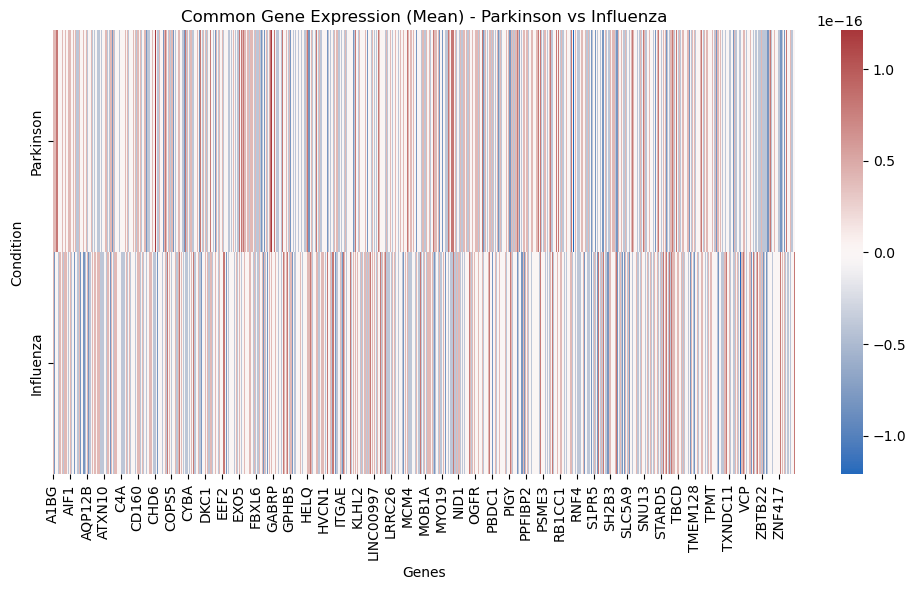

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Load datasets
parkinson_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS5646.csv")
influenza_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\GDS6063.csv")
common_genes_df = pd.read_csv("C:\\Users\\nurana.verdiyeva\\Desktop\\common_genes.csv")

# Remove leading/trailing spaces and lowercase all column names
parkinson_df.columns = parkinson_df.columns.str.strip().str.lower()
influenza_df.columns = influenza_df.columns.str.strip().str.lower()
common_genes_df.columns = common_genes_df.columns.str.strip().str.lower()

# Now the columns will be all lowercase, use 'gene symbol'
parkinson_df = parkinson_df[parkinson_df["gene symbol"].isin(common_genes_df["gene symbol"])]
influenza_df = influenza_df[influenza_df["gene symbol"].isin(common_genes_df["gene symbol"])]


# Step 2: Clean and prepare both datasets
# We only keep rows where 'Gene symbol' is in common_genes
parkinson_df = parkinson_df[parkinson_df["gene symbol"].isin(common_genes_df["gene symbol"])]
influenza_df = influenza_df[influenza_df["gene symbol"].isin(common_genes_df["gene symbol"])]

# Remove duplicated gene symbols by averaging (optional but common)
parkinson_df = parkinson_df.groupby("gene symbol").mean(numeric_only=True)
influenza_df = influenza_df.groupby("gene symbol").mean(numeric_only=True)

# Step 3: Match genes in same order
common_genes = sorted(set(parkinson_df.index).intersection(influenza_df.index))
parkinson_expr = parkinson_df.loc[common_genes]
influenza_expr = influenza_df.loc[common_genes]

# Step 4: (Optional) Normalize expression for comparison
scaler = StandardScaler()
parkinson_scaled = pd.DataFrame(
    scaler.fit_transform(parkinson_expr.T),
    index=parkinson_expr.columns,
    columns=parkinson_expr.index
)
influenza_scaled = pd.DataFrame(
    scaler.fit_transform(influenza_expr.T),
    index=influenza_expr.columns,
    columns=influenza_expr.index
)

# Step 5a: Compute Pearson correlation between diseases (gene-wise)
merged_expr = pd.concat([parkinson_scaled.mean().rename("Parkinson"),
                         influenza_scaled.mean().rename("Influenza")], axis=1)

correlation = merged_expr.corr().iloc[0, 1]
print(f"\n📊 Pearson correlation between Parkinson and Influenza expression (across common genes): {correlation:.3f}")

# Step 5b: Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(merged_expr.T, cmap="vlag", annot=False, cbar=True)
plt.title("Common Gene Expression (Mean) - Parkinson vs Influenza")
plt.xlabel("Genes")
plt.ylabel("Condition")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


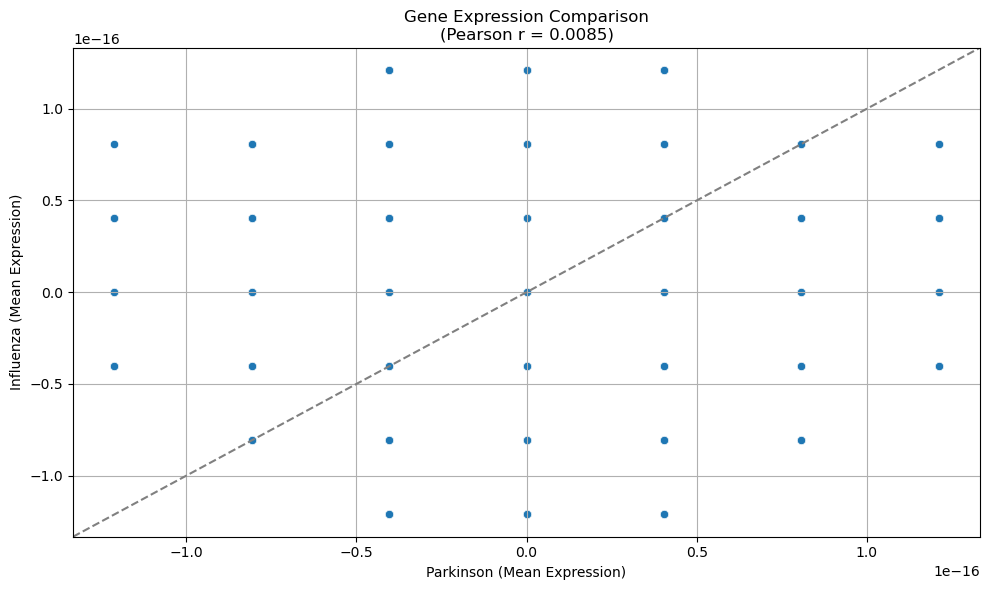

In [16]:
# Scatter plot to visualize correlation between mean expressions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Parkinson', y='Influenza', data=merged_expr)
plt.title(f"Gene Expression Comparison\n(Pearson r = {correlation:.4f})")
plt.xlabel("Parkinson (Mean Expression)")
plt.ylabel("Influenza (Mean Expression)")
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x line
plt.grid(True)
plt.tight_layout()
plt.show()



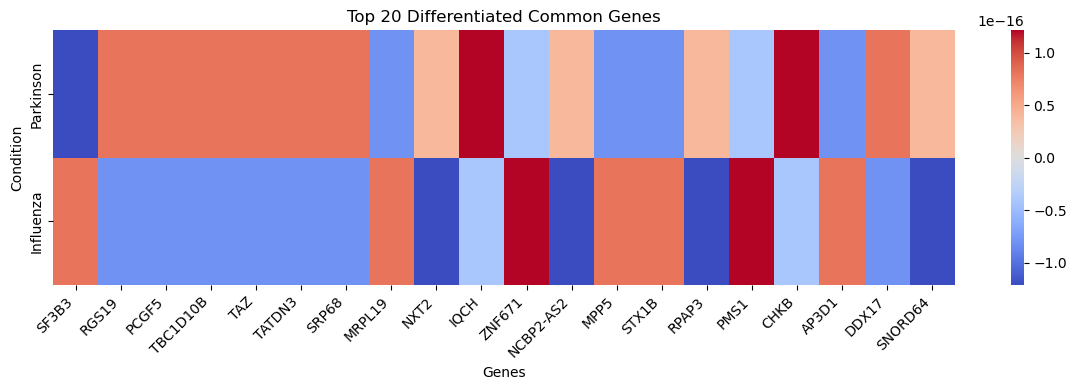

In [17]:
# Compute absolute differences between diseases
merged_expr["abs_diff"] = (merged_expr["Parkinson"] - merged_expr["Influenza"]).abs()

# Sort by difference and take top 20
top_diff_genes = merged_expr.sort_values("abs_diff", ascending=False).head(20).drop(columns="abs_diff")

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(top_diff_genes.T, cmap="coolwarm", annot=False, cbar=True)
plt.title("Top 20 Differentiated Common Genes")
plt.xlabel("Genes")
plt.ylabel("Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## GO (Gene Ontology) Enrichment Analysis

In [35]:
# Performs GO Enrichment Analysis to study biological functions.


# Load the dataset
df = pd.read_csv("Desktop/GDS5646.csv")


# If it's under a different name, correct the column name
# Example of extracting the gene symbols if they are under a different column name
genes = df["Gene symbol"].dropna()  # Ensure no missing values
genes_cleaned = genes.str.upper().str.strip()

unique_genes = genes_cleaned.unique()
pd.DataFrame({"Unique Genes": unique_genes}).to_csv("cleaned_unique_GDS5646.csv", index=False)
# Run GO enrichment on unique genes
#go_results = gp.profile(organism="hsapiens", query=list(unique_to_gds5646))
# Now use the cleaned unique genes list
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Perform GO enrichment
go_results = gp.profile(organism="hsapiens", query=list(unique_genes))

# Save the results
go_results.to_csv("GO_enrichment_cleaned.csv", index=False)
print(go_results.head(10))

C:\Users\Nurana\AppData\Local\Temp\ipykernel_10992\527201460.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Desktop/GDS5646.csv")


  source      native                                       name  \
0  GO:BP  GO:0048518  positive regulation of biological process   
1  GO:BP  GO:0007154                         cell communication   
2  GO:BP  GO:0050794             regulation of cellular process   
3  GO:CC  GO:0005737                                  cytoplasm   
4  GO:BP  GO:0048856           anatomical structure development   
5  GO:BP  GO:0050789           regulation of biological process   
6  GO:BP  GO:0032502                      developmental process   
7  GO:BP  GO:0032501           multicellular organismal process   
8  GO:BP  GO:0050896                       response to stimulus   
9  GO:BP  GO:0051716              cellular response to stimulus   

         p_value  significant  \
0  4.940656e-324         True   
1  4.940656e-324         True   
2  4.940656e-324         True   
3  4.940656e-324         True   
4  4.940656e-324         True   
5  4.940656e-324         True   
6  4.940656e-324         True  

In [9]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Run GO enrichment on unique genes
go_results = gp.profile(organism="hsapiens", query=list(unique_to_gds6063))

# Save results
go_results.to_csv("GO_enrichment_GDS6063.csv", index=False)
print(go_results.head())
go_results.columns

  source      native                                          name  \
0  GO:BP  GO:0032501              multicellular organismal process   
1  GO:CC  GO:0071944                                cell periphery   
2  GO:BP  GO:0003008                                system process   
3  GO:BP  GO:0007186  G protein-coupled receptor signaling pathway   
4  GO:BP  GO:0050877                        nervous system process   

         p_value  significant  \
0  4.431498e-113         True   
1  4.335391e-107         True   
2   1.893811e-97         True   
3   2.544753e-92         True   
4   3.969471e-92         True   

                                         description  term_size  query_size  \
0  "Any biological process, occurring at the leve...       7234        6078   
1  "The broad region around and including the pla...       6269        6370   
2  "A multicellular organismal process carried ou...       2266        6078   
3  "The series of molecular signals initiated by ...       1275 

Index(['source', 'native', 'name', 'p_value', 'significant', 'description',
       'term_size', 'query_size', 'intersection_size', 'effective_domain_size',
       'precision', 'recall', 'query', 'parents'],
      dtype='object')

## KEGG Pathway Analysis

In [10]:
#!pip install bioservices

In [36]:
from bioservices import KEGG

# Initialize KEGG API
kegg = KEGG()

# Example list of shared genes
common_genes = ['TP53', 'BRCA1', 'EGFR']  # Replace with your actual genes

# Retrieve KEGG pathways for shared genes
shared_kegg_pathways = {}

for gene in common_genes:
    gene_info = kegg.find("genes", gene)  # Returns a raw string response
    
    if gene_info:
        # Extract KEGG ID from the response
        first_line = gene_info.split("\n")[0]  # Get first match (if any)
        if first_line:
            kegg_id = first_line.split("\t")[0]  # Extract KEGG ID (before tab character)
            
            # Get full KEGG entry for this gene
            kegg_details = kegg.get(kegg_id)
            
            # Parse KEGG entry
            parsed_details = kegg.parse(kegg_details)
            
            # Extract pathways if available
            if "PATHWAY" in parsed_details:
                shared_kegg_pathways[gene] = parsed_details["PATHWAY"]

# Display pathways associated with each gene
for gene, pathways in shared_kegg_pathways.items():
    print(f"Gene: {gene}")
    for path_id, path_name in pathways.items():
        print(f"  - {path_id}: {path_name}")


Gene: BRCA1
  - hsa04137: Mitophagy - animal
  - hsa04140: Autophagy - animal
Gene: EGFR
  - hsa04668: TNF signaling pathway


In [12]:
# Runs KEGG Pathway Analysis to find related pathways.

from bioservices import KEGG

kegg = KEGG()

# Gene of interest
gene_symbol = "TP53"

# Search KEGG for the gene
gene_info = kegg.find("genes", gene_symbol)

if gene_info:
    # Convert raw string output to a dictionary
    gene_lines = gene_info.split("\n")
    
    # Look for the primary TP53 entry (human gene)
    kegg_id = None
    for line in gene_lines:
        if line.startswith("hsa:7157"):  # TP53's primary KEGG ID for humans
            kegg_id = line.split("\t")[0]
            break  # Stop searching once found

    if kegg_id:
        print(f"Using KEGG ID: {kegg_id}")
        
        # Fetch pathway details
        kegg_details = kegg.get(kegg_id)
        parsed_details = kegg.parse(kegg_details)

        if "PATHWAY" in parsed_details:
            print(f"Pathways for {gene_symbol}:")
            for path_id, path_name in parsed_details["PATHWAY"].items():
                print(f"  - {path_id}: {path_name}")
        else:
            print(f"No pathways found for {gene_symbol}.")
    else:
        print(f"Could not identify the main KEGG ID for {gene_symbol}.")
else:
    print(f"Gene {gene_symbol} not found in KEGG.")


Using KEGG ID: hsa:7157
Pathways for TP53:
  - hsa01522: Endocrine resistance
  - hsa01524: Platinum drug resistance
  - hsa04010: MAPK signaling pathway
  - hsa04071: Sphingolipid signaling pathway
  - hsa04110: Cell cycle
  - hsa04115: p53 signaling pathway
  - hsa04137: Mitophagy - animal
  - hsa04151: PI3K-Akt signaling pathway
  - hsa04210: Apoptosis
  - hsa04211: Longevity regulating pathway
  - hsa04216: Ferroptosis
  - hsa04218: Cellular senescence
  - hsa04310: Wnt signaling pathway
  - hsa04722: Neurotrophin signaling pathway
  - hsa04919: Thyroid hormone signaling pathway
  - hsa05012: Parkinson disease
  - hsa05014: Amyotrophic lateral sclerosis
  - hsa05016: Huntington disease
  - hsa05131: Shigellosis
  - hsa05160: Hepatitis C
  - hsa05161: Hepatitis B
  - hsa05162: Measles
  - hsa05163: Human cytomegalovirus infection
  - hsa05165: Human papillomavirus infection
  - hsa05166: Human T-cell leukemia virus 1 infection
  - hsa05167: Kaposi sarcoma-associated herpesvirus infe

## Statistical Analysis

In [13]:
# Tests Normality of gene expression data.

from scipy.stats import fisher_exact

# Example: Fisher's test on gene count differences
table = [[len(common_genes), len(unique_to_gds5646)],
         [len(unique_to_gds6063), len(genes1.union(genes2))]]

odds_ratio, p_value = fisher_exact(table)
print(f"Fisher’s Exact Test: p={p_value}")
print(f"Table: {table}")


from scipy.stats import chi2_contingency

chi2, p, _, _ = chi2_contingency(table)
print(f"Chi-Square Test p-value: {p}")


Fisher’s Exact Test: p=0.1614709966431841
Table: [[3, 20], [8183, 20782]]
Chi-Square Test p-value: 0.16518537564222652


In [14]:
print(pd_genes.columns)
print([col for col in pd_genes.columns if "GSM" in col])
print(pd_genes.head())


Index(['GSM1318547', 'GSM1318548', 'GSM1318549', 'GSM1318550', 'GSM1318551',
       'GSM1318552', 'GSM1318553', 'GSM1318554', 'GSM1318555', 'GSM1318556',
       'Gene symbol'],
      dtype='object')
['GSM1318547', 'GSM1318548', 'GSM1318549', 'GSM1318550', 'GSM1318551', 'GSM1318552', 'GSM1318553', 'GSM1318554', 'GSM1318555', 'GSM1318556']
     GSM1318547  GSM1318548  GSM1318549  GSM1318550  GSM1318551  GSM1318552  \
9      50894.30    45431.00    47569.40    49315.00    45882.20    43339.20   
10      1600.24     2329.44     2360.47     1665.35     2609.02     2209.33   
785    22297.60    22865.60    19891.10    19758.90    21512.10    19618.00   
786      147.00      106.88       98.56      129.18      105.00      129.32   
795     1107.02     1161.17     1385.54     1312.47     1182.85     1482.06   

     GSM1318553  GSM1318554  GSM1318555  GSM1318556 Gene symbol  
9      50943.50    48679.40    43809.20    39366.20      EEF1A1  
10      2746.87     2684.89     2342.86     2493.88  

In [15]:
from scipy.stats import shapiro

expression_columns = [col for col in pd_genes.columns if col.startswith("GSM")]
if expression_columns:
    stat, p = shapiro(pd_genes[expression_columns[0]])  # Use first numeric column
    print(f"Shapiro-Wilk Test: p={p}")
else:
    print("No 'GSM' columns found.")


Shapiro-Wilk Test: p=1.5776911376391932e-129


C:\Users\Nurana\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16460.
  res = hypotest_fun_out(*samples, **kwds)


## Visualization

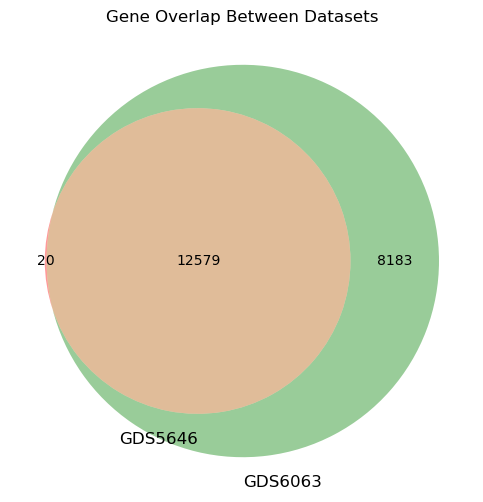

In [17]:
# Venn Diagram for Gene Overlap

from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
venn2([genes1, genes2], set_labels=("GDS5646", "GDS6063"))
plt.title("Gene Overlap Between Datasets")
plt.show()


In [18]:
print(go_results.columns)

Index(['source', 'native', 'name', 'p_value', 'significant', 'description',
       'term_size', 'query_size', 'intersection_size', 'effective_domain_size',
       'precision', 'recall', 'query', 'parents'],
      dtype='object')


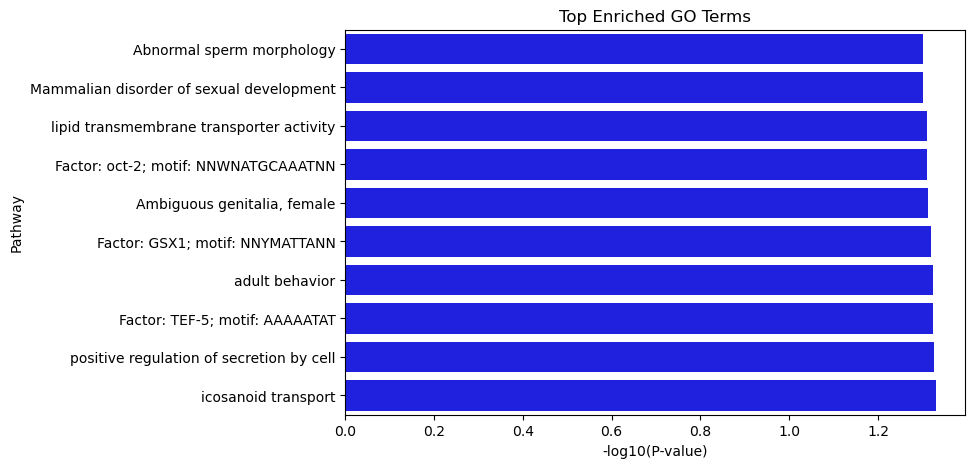

In [20]:
# GO Enrichment Visualization

import seaborn as sns
import numpy as np
# Select top 10 enriched pathways
top_pathways = go_results.nlargest(10, "p_value")

plt.figure(figsize=(8, 5))
sns.barplot(y=top_pathways["name"], x=-np.log10(top_pathways["p_value"]), color="blue")
plt.xlabel("-log10(P-value)")
plt.ylabel("Pathway")
plt.title("Top Enriched GO Terms")
plt.show()


In [36]:
#pip install keggrest

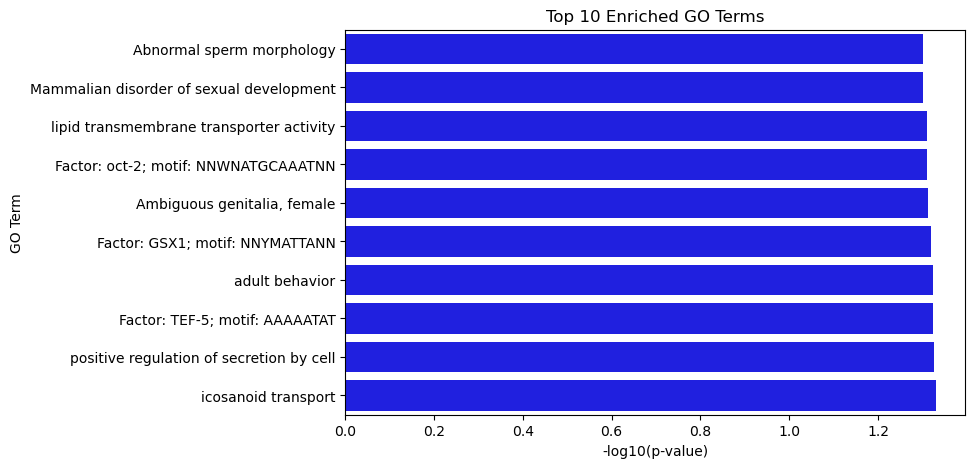

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

top_pathways2 = go_results.nlargest(10, "p_value")

plt.figure(figsize=(8, 5))
sns.barplot(y=top_pathways2["name"], x=-np.log10(top_pathways2["p_value"]), color="blue")

#sns.barplot(y=go_results['name'].head(10), x=-go_results['p_value'].head(10), hue=go_results['name'], legend=False)
plt.xlabel("-log10(p-value)")
plt.ylabel("GO Term")
plt.title("Top 10 Enriched GO Terms")
plt.show()



C:\Users\Nurana\AppData\Local\Temp\ipykernel_10992\1090260648.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=count_df, x='Num_Pathways', palette='mako')


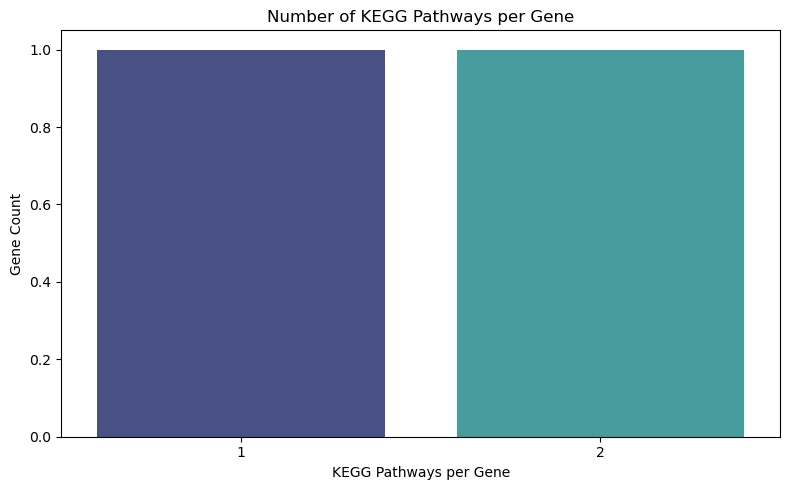

In [30]:
# Visualize KEGG pathways (example bar plot)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

kegg_counts = [len(v) for v in shared_kegg_pathways.values()]
count_df = pd.DataFrame({'Num_Pathways': kegg_counts})

plt.figure(figsize=(8, 5))
sns.countplot(data=count_df, x='Num_Pathways', palette='mako')
plt.title("Number of KEGG Pathways per Gene")
plt.xlabel("KEGG Pathways per Gene")
plt.ylabel("Gene Count")
plt.tight_layout()
plt.show()



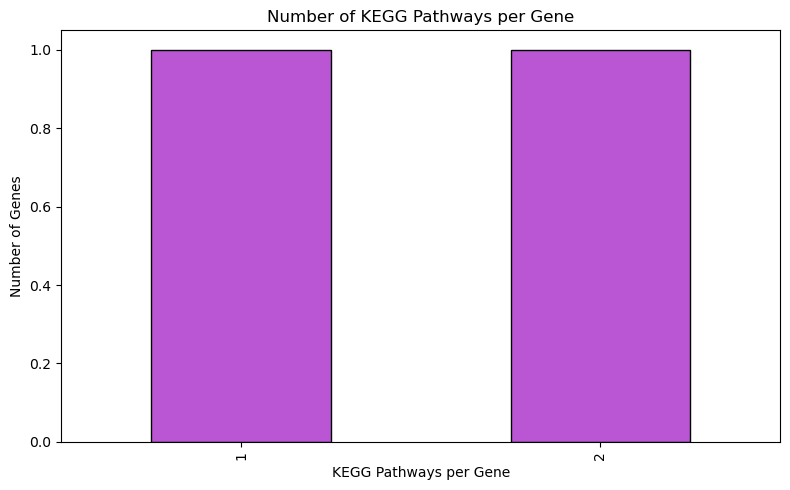

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Count how many genes have N pathways
kegg_counts = pd.Series([len(v) for v in shared_kegg_pathways.values()])
count_per_pathway = kegg_counts.value_counts().sort_index()

plt.figure(figsize=(8, 5))
count_per_pathway.plot(kind='bar', color='mediumorchid', edgecolor='black')
plt.title("Number of KEGG Pathways per Gene")
plt.xlabel("KEGG Pathways per Gene")
plt.ylabel("Number of Genes")
plt.tight_layout()
plt.show()
